# Causality Tutorial Exercises – R

Contributors: Rune Christiansen, Jonas Peters, Niklas Pfister, Sorawit Saengkyongam, Sebastian Weichwald.
The MIT License applies; copyright is with the authors.
Some exercises are adapted from "Elements of Causal Inference: Foundations and Learning Algorithms" by J. Peters, D. Janzing and B. Schölkopf.


# Exercise 1 – Structural Causal Model

Let's first draw a sample from an SCM

In [2]:
set.seed(1)

n <- 200
C <- rnorm(n)
A <- 0.8*rnorm(n)
K <- A + 0.1*rnorm(n)
X <- C - 2*A + 0.2*rnorm(n)
F <- 3*X + 0.8*rnorm(n)
D <- -2*X + 0.5*rnorm(n)
G <- D + 0.5*rnorm(n)
Y <- 2*K - D + 0.2*rnorm(n)
H <- 0.5*Y + 0.1*rnorm(n)

data.obs <- cbind(C, A, K, X, F, D, G, Y, H)

### (a)

What are the parents and children of $X$ in the above SCM ?

Take a pair of variables and think about whether you expect this pair to be dependent
(at this stage, you can only guess, later you will have tools to know). Check empirically.

#### Solution

### (b)

Generate a sample of size 300 from the interventional distribution $P_{\mathrm{do}(X=\mathcal{N}(2, 1))}$
and store the data matrix as `data.int`.

#### Solution

In [3]:
set.seed(1)

n <- 300
C <- rnorm(n)
A <- 0.8*rnorm(n)
K <- A + 0.1*rnorm(n)
X <- rnorm(n,2,1)
F <- 3*X + 0.8*rnorm(n)
D <- -2*X + 0.5*rnorm(n)
G <- D + 0.5*rnorm(n)
Y <- 2*K - D + 0.2*rnorm(n)
H <- 0.5*Y + 0.1*rnorm(n)

data.int <- cbind(C, A, K, X, F, D, G, Y, H)

### (c)

Do you expect the marginal distribution of $Y$ to be different in both samples?

#### Solution

Yes, because X is a parent of D which is a parent of Y, so the marginal distribtution will be different.


### (d)

Do you expect the joint distribution of $(A, Y)$ to be different in both samples?

#### Solution

Yes, because the marginal distribution of Y is different.

### (e)

Check your answers to c) and d) empirically.

#### Solution

# Exercise 2 – Adjusting

[1] "Empirical check for marginal distribution of Y"
[1] "Summary statistics for Y (observational):"
     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
-6.905618 -1.806645  0.199556  0.004279  1.756655  6.639935 
[1] "\nSummary statistics for Y (interventional):"
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 -3.953   2.118   3.894   3.908   5.740  10.668 
[1] "\nEmpirical check for joint distribution of (A, Y)\n"
[1] "Correlation between A and Y (observational):"
[1] -0.6216456
[1] "\nCorrelation between A and Y (interventional):"
[1] 0.6244888


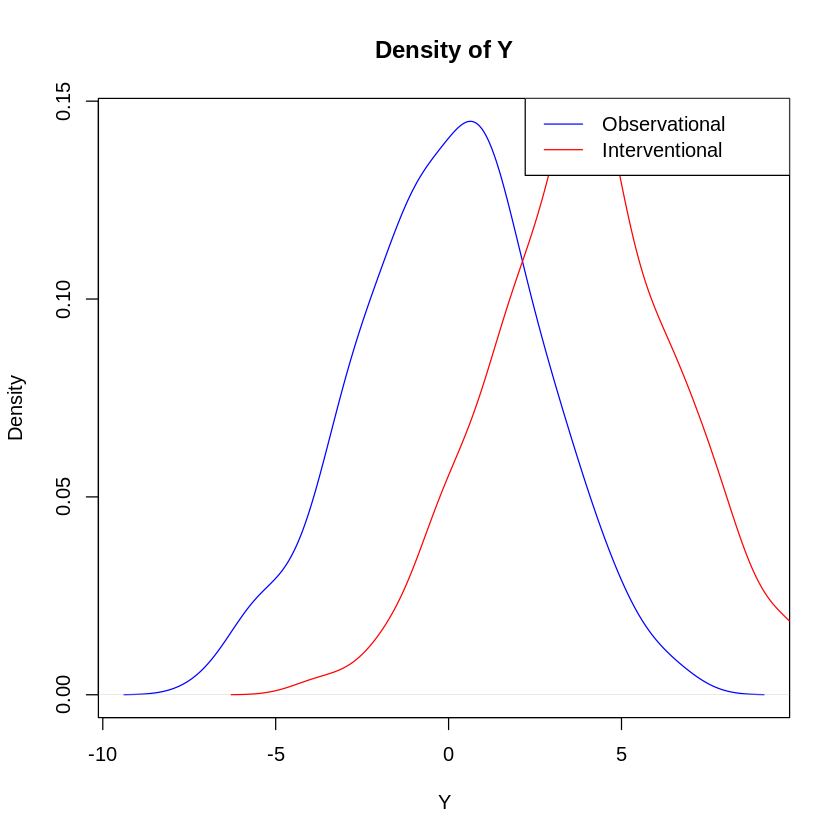

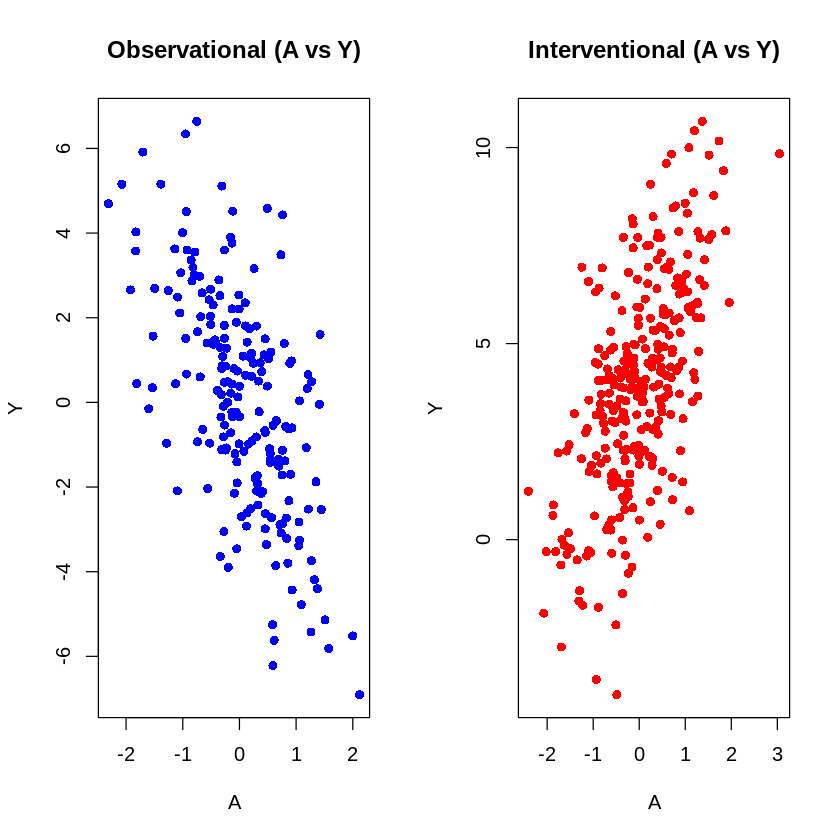

In [5]:
print('Empirical check for marginal distribution of Y')
print('Summary statistics for Y (observational):')
print(summary(data.obs[, 'Y']))
print('\nSummary statistics for Y (interventional):')
print(summary(data.int[, 'Y']))

# Density plot for Y
plot(density(data.obs[, 'Y']), col = 'blue', main = 'Density of Y', xlab = 'Y')
lines(density(data.int[, 'Y']), col = 'red')
legend('topright', c('Observational', 'Interventional'), col = c('blue', 'red'), lty = 1)

print('\nEmpirical check for joint distribution of (A, Y)
')
print('Correlation between A and Y (observational):')
print(cor(data.obs[, 'A'], data.obs[, 'Y']))
print('\nCorrelation between A and Y (interventional):')
print(cor(data.int[, 'A'], data.int[, 'Y']))

# Scatter plot for (A, Y)
par(mfrow=c(1,2)) # Arrange plots in 1 row, 2 columns
plot(data.obs[, 'A'], data.obs[, 'Y'], col = 'blue', main = 'Observational (A vs Y)', xlab = 'A', ylab = 'Y', pch = 16)
plot(data.int[, 'A'], data.int[, 'Y'], col = 'red', main = 'Interventional (A vs Y)', xlab = 'A', ylab = 'Y', pch = 16)
par(mfrow=c(1,1)) # Reset plot layout

ERROR: Error: object 'p1' not found


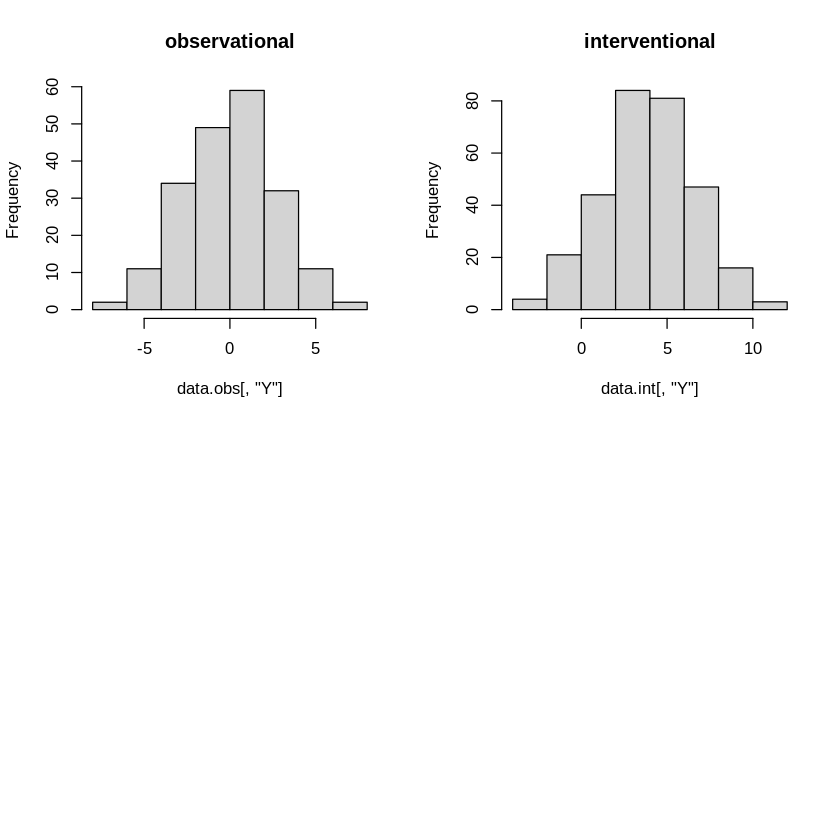

In [8]:
par(mfrow=c(2,2))
p1 <- hist(data.obs[, "Y"], main="observational", plot=T)
p2 <- hist(data.int[, "Y"], main="interventional", plot=T)
plot(p1, col=rgb(0,0,1,0.25), xlim=c(-10, 15))
plot(p2, col=rgb(1,0,0,0.25), add=T, xlim=c(-10, 15))

plot(data.obs[, "A"], data.obs[,"Y"])
points(data.int[, "A"], data.int[,"Y"], col="red")


![DAG](https://raw.githubusercontent.com/sweichwald/causality-tutorial-exercises/main/data/Exercise-ANM.png)

Suppose we are given a fixed DAG (like the one above).

### (a)
What are valid adjustment sets (VAS) used for?

#### Solution

Double-click (or enter) to edit

### (b)

Assume we want to find a VAS for the causal effect from $X$ to $Y$.
What are general recipies (plural 😉) for constructing VASs (no proof)?
Which sets are VAS in the DAG above?

#### Solution

Double-click (or enter) to edit

### (c)

The following code samples from an SCM. Perform linear regressions using different VAS and compare the regression coefficient against the causal effect from $X$ to $Y$.

In [ ]:
set.seed(1)

n <- 200
C <- rnorm(n)
A <- 0.8*rnorm(n)
K <- A + 1.1*rnorm(n)
X <- C - 2*A + 0.2*rnorm(n)
F <- 3*X + 0.8*rnorm(n)
D <- -2*X + 0.5*rnorm(n)
G <- D + 0.5*rnorm(n)
Y <- 2*K - D + 0.2*rnorm(n)
H <- 0.5*Y + 0.1*rnorm(n)

data.obs <- cbind(C, A, K, X, F, D, G, Y, H)

#### Solution

### (d)

Why could it be interesting to have several options for choosing a VAS?

#### Solution

Double-click (or enter) to edit

### (e)

If you indeed have access to several VASs, what would you do?

#### Solution

Double-click (or enter) to edit

# Exercise 3 – Independence-based Causal Structure Learning

### (a)

Assume $P^{X,Y,Z}$ is Markov and faithful wrt. $G$. Assume all (!) conditional independences are

$$
\newcommand{\indep}{{\,⫫\,}}
\newcommand{\dep}{\not{}\!\!\indep}
$$

$$X \dep Z \mid \emptyset$$

(plus symmetric statements). What is $G$?

#### Solution

Double-click (or enter) to edit

### (b)

Assume $P^{W,X,Y,Z}$ is Markov and faithful wrt. $G$. Assume all (!) conditional independences are

$$\begin{aligned}
(Y,Z) &\indep W \mid \emptyset \\
W &\indep Y \mid (X,Z) \\
(X,W) &\indep Y | Z
\end{aligned}
$$

(plus symmetric statements). What is $G$?

#### Solution

Double-click (or enter) to edit

# Exercise 4 – Additive Noise Models

Set-up required packages:

In [ ]:
# set up – not needed when run on mybinder
# if needed (colab), change FALSE to TRUE and run cell
if (FALSE) {
  install.packages('dHSIC')
}

In [ ]:
library(mgcv)
library(dHSIC)

Let's load and plot some real data set:

In [ ]:
# Load some real data set
real.dat <- read.csv('https://raw.githubusercontent.com/sweichwald/causality-tutorial-exercises/main/data/Exercise-ANM.csv')
Y <- real.dat[, "Y"]
X <- real.dat[, "X"]

# Let us plot the data
par(mfrow=c(1,1))
plot(X, Y, pch = 19, cex = .8)

### (a)

Do you believed that $X \to Y$ or that $X \gets Y$? Why?

#### Solution

Double-click (or enter) to edit

### (b)

$$
\newcommand{\indep}{{\,⫫\,}}
\newcommand{\dep}{\not{}\!\!\indep}
$$

Let us now try to get a more statistical answer. We have heard that we cannot
have  
$$Y = f(X) + N_Y,\ N_Y \indep X$$
and
$$X = g(Y) + N_X,\ N_X \indep Y$$
at the same time.

Given a data set over $(X,Y)$,
we now want to decide for one of the two models.

Come up with a method to do so.

Hints:
* `gam(B ∼ s(A))$residuals` provides residuals when regressing $B$ on $A$.
* `dhsic.test` (with `method = "gamma"`) can be used as an independence test.

#### Solution

### (c)

Assume that the error terms are Gaussian with zero mean and variances
$\sigma_X^2$ and $\sigma_Y^2$, respectively.
The maximum likelihood for DAG G is
then proportional to
$-\log(\mathrm{var}(R^G_X)) - \log(\mathrm{var}(R^G_Y))$,
where $R^G_X$ and $R^G_Y$ are the residuals obtained from regressing $X$ and $Y$ on
their parents in $G$, respectively (no proof).

Find the maximum likelihood solution.

#### Solution

# Exercise 5 – Invariant Causal Prediction

### (a)

Generate some observational and interventional data:

In [ ]:
# Generate n=1000 observations from the observational distribution
na <- 1000
Xa <- rnorm(na)
Ya <- 1.5*Xa + rnorm(na)

# Generate n=1000 observations from an interventional distribution
nb <- 1000
Xb <- rnorm(nb, 2, 1)
Yb <- 1.5*Xb + rnorm(nb)
red <- rgb(1,0,0,alpha=0.4)
blue <- rgb(0,0,1,alpha=0.4)

# plot Y vs X
plot(Xa,Ya,pch=16,col=blue,xlim=range(c(Xa,Xb)),ylim=range(c(Ya,Yb)),xlab="X",ylab="Y")
points(Xb,Yb,pch=17,col=red)
legend("topright",c("observational","interventional"),pch=c(16,17),col=c(blue,red),inset=0.02)

Look at the above plot. Is the predictor $\{X\}$ an invariant set, that is (roughly speaking), does $Y \mid X = x$ have the same distribution in the red and blue data?

#### Solution

Double-click (or enter) to edit

### (b)
We now consider data over a response and three covariates $X1, X2$, and $X3$
and try to infer $\mathrm{pa}(Y)$. To do so, we need to find all sets for which this
invariance is satisfied.

In [ ]:
data <- as.matrix(read.csv('https://raw.githubusercontent.com/sweichwald/causality-tutorial-exercises/main/data/Exercise-ICP.csv'))
pairs(data, col = c(rep(1,140), rep(2,80)))

# The code below plots the residuals versus fitted values for all sets of
# predictors.
# extract response and predictors
Y <- data[,1]
Xmat  <- data[,2:4]
S <- list( c(1), c(2), c(3), c(1,2), c(1,3), c(2,3), c(1,2,3))
resid <- fitted <- vector("list", length(S))
for(i in 1:length(S)){
  modelfit <- lm.fit(Xmat[,S[[i]],drop=FALSE], Y)
  resid[[i]] <- modelfit$residuals
  fitted[[i]] <- modelfit$fitted.values
}
env <- c(rep(0,140),rep(1,80))
par(mfrow=c(2,2))
red <- rgb(1,0,0,alpha=0.4)
blue <- rgb(0,0,1,alpha=0.4)
names <- c("X1", "X2", "X3", "X1, X2", "X1, X3", "X2, X3", "X1, X2, X3")
plot((1:length(Y))[env==0], Y[env==0], pch=16, col=blue, xlim=c(0,220), ylim=range(Y), xlab="index", ylab="Y", main="empty set")
points((1:length(Y))[env==1], Y[env==1], pch=17, col=red)
legend("topleft",c("observational","interventional"),pch=c(16,17),col=c(blue,red),inset=0.02)
for(i in 1:length(S)){
  plot(fitted[[i]][env==0], resid[[i]][env==0], pch=16, col=blue, xlim=range(fitted[[i]]), ylim=range(resid[[i]]), xlab="fitted values", ylab="residuals", main=names[i])
  points(fitted[[i]][env==1], resid[[i]][env==1], pch=17, col=red)
  legend("topleft",c("observational","interventional"),pch=c(16,17),col=c(blue,red),inset=0.02)
}


Which of the sets are invariant? (There are two plots with four scatter plots each.)

#### Solution

Double-click (or enter) to edit

### (c)
What is your best guess for $\mathrm{pa}(Y)$?

#### Solution

Double-click (or enter) to edit

### (d)
**(optional, and R only)**

Use the function ICP to check your result.

In [ ]:
# set up – not needed when run on mybinder
# if needed (colab), change FALSE to TRUE and run cell
if (FALSE) {
  install.packages('InvariantCausalPrediction')
}

In [ ]:
library(InvariantCausalPrediction)

#### Solution

# Exercise 6 - Confounding and selection bias

### Generate data

We start by generating data from the following SCM

In [ ]:
generate_data <- function(seed){
    set.seed(seed)
    n <- 200
    V <- rbinom(n, 1, 0.2)
    W <- 3*V + rnorm(n)
    X <- V + rnorm(n)
    Y <- X + W^2 + 1 + rnorm(n)
    Z <- X + Y + rnorm(n)
    data.obs <- data.frame(V=V, W=W, X=X, Y=Y, Z=Z)
    return(data.obs)
}

data.obs <- generate_data(1)

# Visualize data set
pairs(data.obs)

Assume now that we know the causal ordering induced by the SCM and that
* $X$ is a treatment variable,
* $Y$ is the response and
* $(V, W, Z)$ are additional covariates.

Furthermore we will assume a partially linear outcome model, i.e.,
$$Y = \theta X + g(V, W) + \epsilon\quad \text{with}\quad\mathbb{E}[\epsilon\mid X, V, W]=0.$$

We are interested in estimating the causal effect of $X$ on $Y$, corresponding to the parameter $\theta$ in the partially linear model.

### Background: Confounding and selection bias

Ignoring the causal structure can lead to wrong conclusions. In the following exercise, we will see the two most important types of bias that may occur:
* **Confounding bias:** Bias arising because of unaccounted variables that have an effect on both treatment and response.
* **Selection bias:** Bias arising due to conditioning on descendents of the response. This can occur either if we only observe a subset of the entire sample or if we mistakenly include a descendent of the response in the outcome model.

### Exercises

### (a)

In the code below we fitted several different outcome models. Compare the resulting coefficients for $X$. Which regressions appear to lead to unbiased estimates of the causal effect?

In [ ]:
library(gam)

# linear model of Y on X
lin_YX <- lm(Y ~ X, data=data.obs)
# linear model of Y on X and V
lin_YV <- lm(Y ~ X + V, data=data.obs)
# linear model Y on X and W
lin_YW <- lm(Y ~ X + W, data=data.obs)
# gam model of Y on X and s(W)
gam_YW <- gam(Y ~ X + s(W), data=data.obs)
# gam model of Y on X, V and s(W)
gam_YVW <- gam(Y ~ X + V + s(W), data=data.obs)
# gam model of Y on X, s(W), s(Z)
gam_YWZ <- gam(Y ~ X + s(W) + s(Z), data=data.obs)

# Print each model
results = list(linear_X = unname(coefficients(lin_YX)['X']),
               linear_V = unname(coefficients(lin_YV)['X']),
               linear_W = unname(coefficients(lin_YW)['X']),
               gam_W = unname(coefficients(gam_YW)['X']),
               gam_VW = unname(coefficients(gam_YVW)['X']),
               gam_VWZ = unname(coefficients(gam_YWZ)['X']))
results

#### Solution

Double-click (or enter) to edit

### (b)
List all valid adjustment sets for this causal structure.

#### Solution

Double-click (or enter) to edit

### (c)
Assume now that you only have access to the subset $\texttt{data.cond}$ constructed in the code snippet below. Use a gam regression Y ~ X + s(W) to estimate the causal effect. What do you observe?

In [ ]:
data.cond = data.obs[data.obs$Z<1,]

#### Solution

Double-click (or enter) to edit

# Exercise 7 - Estimating causal effects

We use the same data $\texttt{data.obs}$ as in Exercise 6 and make the same assumptions. In this exercise you will go over the following approaches for estimating the causal effect from $X$ to $Y$:
* **Covariate adjustment:** Directly estimate the outcome model based on a valid adjustment set and use it estimate the causal effect.
* **Propensity score matching:** Estimate the propensity score, use it to match samples and then estimate the causal effect based on the matched data.
* **Inverse probability weighting:** Estimate the propensity score, use it to weight the samples and then estimate the causal effect based on the weighted sample.
* **Double machine learning:** Estimate a regression function for both the propensity model and the outcome model and combine them to estimate the causal effect.

### (a)
In this part of the exercise, we will compute a covariate adjustment estimator using the library $\texttt{gam}$.

Implement a function $\texttt{causal\_effect\_adjustment}$ that the data $\texttt{data.obs}$ as input and computes the covariate adjustment estimator with the gam equation Y ~ X + s(W).

#### Solution

In [ ]:
library(gam)

# Function to estimate causal effect based on covariate adjustment
causal_effect_adjustment <- function(data){
    ### ADD CODE HERE ###
}

# Estimate causal effect
ate_adjustment <- causal_effect_adjustment(data.obs)
ate_adjustment

### (b)
In this part of the exercise, we will compute a propensity matching estimator using the library $\texttt{Matchit}$.

Since most matching methods apply only to binary treatments, we first discretize the treatment $X$, compute a binary treatment effect and then backtransform with an adjustment factor. The following code snippet explains this (you can later copy this to your propensity score estimation function).

In [ ]:
library(MatchIt)

# Create binary treatment (more complicated matching procedures also exist of continuous responses)
data.matching <- data.obs
T <- as.numeric(data.obs$X > median(data.obs$X))
upperT <- mean(data.obs$X[T == 1])
lowerT <- mean(data.obs$X[T == 0])
adjust_factor <- upperT-lowerT
data.matching$T <- T
print(adjust_factor)

# Without confounding the following estimator would be unbiased
lmfit <- lm(Y ~ T, data = data.matching)
coefficients(lmfit)['T']/adjust_factor

We will use the $\texttt{MatchIt}$ package. First, we need to select an appropriate matching procedure. Consider the following two options, which is preferable?

In [ ]:
# Create a matching object without matching to check if confounding exists
match0 <- matchit(T ~ V + W, data = data.matching,
                  method = NULL, distance = "glm")
summary(match0)
plot(match0, type="density")

In [ ]:
# Matching Option 1: Using coarsend exact matching method using W
match1 <- matchit(T ~ W, data = data.matching,
                  method = "cem", distance="glm")
summary(match1)
plot(match1, type="density")

In [ ]:
# Matching Option 2: Using exact matching (matches the covariate V directly)
match2 <- matchit(T ~ V, data = data.matching,
                  method = "exact")
summary(match2)
plot(match2, type="density")

Use the selected matching procedure to implement a function $\texttt{causal\_effect\_matching}$ that takes the data $\texttt{data.obs}$ as input and computes the propensity score matching estimator of the causal effect of $X$ on $Y$.

*Hint: Use the code at the beginning of the question as the first part of your function.*

#### Solution

In [ ]:
# Function to estimate causal effect based matching
causal_effect_matching <- function(data){
    # Discretize
    data.matching <- data
    T <- as.numeric(data$X > median(data$X))
    upperT <- mean(data$X[T == 1])
    lowerT <- mean(data$X[T == 0])
    adjust_factor <- upperT-lowerT
    data.matching$T <- T

    ### APPLY MATCHING HERE ###

    data.matched <- match.data(match2)
    # Compute causal effect
    fit_matched <- lm(Y ~ T, data = data.matched, weights=weights)
    return(unname(coefficients(fit_matched)['T'])/adjust_factor)
}

# Estimate causal effect
ate_matching <- causal_effect_matching(data.obs)
ate_matching

### (c)
In this part of the exercise, we will compute an inverse probability weighting estimator using the library $\texttt{WeightIt}$.

In [ ]:
library(WeightIt)

# Fit a weightit object based on the covariates (V, W)
weight_obj <- weightit(X ~ V + W, data = data.obs, estimand = "ATE", method = "glm")
weight_obj
summary(weight_obj)

# Plot a histogram of the weights
hist(weight_obj$weights)

Use the code block above to implement a function $\texttt{causal\_effect\_weighting}$ that the data $\texttt{data.obs}$ as input and computes the inverse probablity weighting estimator.

#### Solution

In [ ]:
# Function to estimate causal effect based on inverse probability weighting
causal_effect_weighting <- function(data){
    ### ADD CODE HERE ###
}

# Estimate causal effect
ate_weighting <- causal_effect_weighting(data.obs)
ate_weighting

### (d)
In this part of the exercise, we will compute a double machine learning estimator using the library $\texttt{DoubleML}$.

Go over the following code and try to understand the individual steps.

In [ ]:
# Load packages (mlr3 packages are required to specify the ML learners)
library(DoubleML)
library(mlr3)
library(mlr3learners)
# Suppress output of mlr3 learners during estimation
lgr::get_logger("mlr3")$set_threshold("warn")


# Function to estimate causal effect based on double machine learning
causal_effect_dml <- function(data){
    # Remove Z as all variables in data will be treated as valid adjustments by DoubleML package
    data$Z <- NULL

    # Step 1:
    # Format the data (this object encodes the causal structure)
    obj_dml_data = DoubleMLData$new(data, y_col = "Y", d_cols = "X")

    # Step 2:
    # Learner for Y given covariates (V, W) - using random forest from ranger (other learners are possible)
    ml_l = lrn("regr.ranger", num.trees = 100, mtry = 2, min.node.size = 2, max.depth = 5)
    # Learner for X given covariates (V, W) - using random forest from ranger (other learners are possible)
    ml_m = lrn("regr.ranger", num.trees = 100, mtry = 2, min.node.size = 2, max.depth = 5)

    # Step 3:
    # Setup DML task
    doubleml_plr = DoubleMLPLR$new(obj_dml_data,
                                   ml_l, ml_m,
                                   n_folds = 2,
                                   score = "partialling out")

    # Fit DML
    doubleml_plr$fit()
    # you can also look at: doubleml_plr$summary()

    return(unname(doubleml_plr$all_coef[1]))
}

# Estimate causal effect
ate_weighting <- causal_effect_dml(data.obs)

### (e)
In this part of the exercise, we will compare all estimators using a simulation study.

Run $10$ repeptitions of a simulation study, where in each step you create a new data sets using the $\texttt{generate\_data}$ function and then applying all of the estimators constructed in the exercises above. Create a boxplot of the results.

#### Solution